In [2]:
%load_ext autoreload
%autoreload 2

In [67]:
import model.SocialLSTM as s
import torch
import torch.optim as optim
import torch.nn as nn

import utils.slstm_utils as slstm_utils
import os

In [68]:
#parameters
obs_len = 15
pred_len = 5
grid_size = 4
hidden_dim = 128
pos_embed_dim = 64
grid_embed_dim = 64
dropout = 0.0
learning_rate = 1e-3
epochs = 30

In [61]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:


current_dir = os.getcwd()

file_path = os.path.join(current_dir, "data","annotations","bookstore","video0", "annotations.txt")
processed_df = slstm_utils.data_cleaning(file_path)
agent_position_dict, frame_ids,frame_id_to_orig = slstm_utils.generate_frame_to_cordinate_map(processed_df)
agent_idx_lookup,idx_to_agent_id = slstm_utils.agent_hidden_idx_lookup(processed_df)
sequences = slstm_utils.generate_frame_sequences(frame_ids,obs_len=obs_len, pred_len=pred_len, stride=5)
train_split = int(0.8 * len(sequences))
print(len(sequences))
print(train_split)
train_sequenes = sequences[:train_split]
test_sequenes = sequences[train_split:]


1330
1064


In [275]:
#print(frame_ids)

In [69]:
max_no_agents = len(agent_idx_lookup)
model = s.SocialLSTM( pos_embedding_size=pos_embed_dim, grid_embedding_size=grid_embed_dim,
                   hidden_dim=hidden_dim, grid_size=grid_size, dropout=dropout, max_agents=max_no_agents)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

In [ ]:

#sequences = sequences[0:1000]
print(len(sequences))
epoch_list = []
loss_list = []
epoch_list_dim = []
loss_list_dim = []
for epoch in range(epochs):
    print(" starting epoch ",epoch)
    total_loss = 0.0
    for window in train_sequenes:
    
        input_tensor , mask_tensor = slstm_utils.generate_tensor_from_frames(window,agent_position_dict,agent_idx_lookup )
        social_grid_tensor = slstm_utils.compute_social_grids(input_tensor,mask_tensor)

        input_tensor = input_tensor.to(device)
        mask_tensor = mask_tensor.to(device)
        social_grid_tensor = social_grid_tensor.to(device)
        max_no_agents = input_tensor.size(1)
        # obs_input = input_tensor[:obs_len]              # [8, max_agents, 2]
        # obs_social_grid_tensor = social_grid_tensor[:obs_len]
        # obs_mask = mask_tensor[:obs_len]

        hidden_states = torch.zeros(max_no_agents, hidden_dim, device=device)
        cell_states = torch.zeros(max_no_agents, hidden_dim, device=device)
        
        

        outputs, hidden_states, cell_states = model(input_tensor, social_grid_tensor, hidden_states, cell_states, mask_tensor)
        

        predicted = outputs[obs_len:]  # future frames
        target = input_tensor[obs_len:]
        target_mask = mask_tensor[obs_len:].unsqueeze(-1)
        # pred_len = input_tensor.size(0) - obs_len
        # predicted = []
        # last_positions = obs_input[-1]

        # for t in range(pred_len):
        #     grid_t = slstm_utils.compute_social_grids(last_positions.unsqueeze(0), obs_mask[-1:].unsqueeze(0))  # shape [1, max_agents, grid_cells, max_agents]
        #     grid_t = grid_t.to(device)
        #     out, hidden_states, cell_states = model(last_positions.unsqueeze(0), grid_t, hidden_states, cell_states, obs_mask[-1:].unsqueeze(0))
        #     last_positions = out[0]  
        #     predicted.append(last_positions)
        
        # predicted = torch.stack(predicted) 
        # target = input_tensor[obs_len:]   
        # target_mask = mask_tensor[obs_len:].unsqueeze(-1)
        #print(predicted)
        loss = criterion(predicted * target_mask, target * target_mask)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
           

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_sequenes):.4f}")
    epoch_list.append(epoch+1)
    loss_list.append(total_loss/len(train_sequenes))


1330
 starting epoch  0
Epoch [1/30] Loss: 58179.3024
 starting epoch  1
Epoch [2/30] Loss: 47463.6953
 starting epoch  2
Epoch [3/30] Loss: 39151.8303
 starting epoch  3
Epoch [4/30] Loss: 31930.0992
 starting epoch  4
Epoch [5/30] Loss: 25061.9550
 starting epoch  5
Epoch [6/30] Loss: 19198.9418
 starting epoch  6
Epoch [7/30] Loss: 15231.3825
 starting epoch  7
Epoch [8/30] Loss: 12592.2959
 starting epoch  8
Epoch [9/30] Loss: 10246.4503
 starting epoch  9
Epoch [10/30] Loss: 9054.4951
 starting epoch  10
Epoch [11/30] Loss: 8314.9341
 starting epoch  11
Epoch [12/30] Loss: 7183.4010
 starting epoch  12
Epoch [13/30] Loss: 6459.2434
 starting epoch  13
Epoch [14/30] Loss: 5824.5392
 starting epoch  14
Epoch [15/30] Loss: 5208.6263
 starting epoch  15
Epoch [16/30] Loss: 4569.6594
 starting epoch  16
Epoch [17/30] Loss: 3861.9008
 starting epoch  17
Epoch [18/30] Loss: 3263.8588
 starting epoch  18
Epoch [19/30] Loss: 2706.1963
 starting epoch  19
Epoch [20/30] Loss: 2281.2314
 star

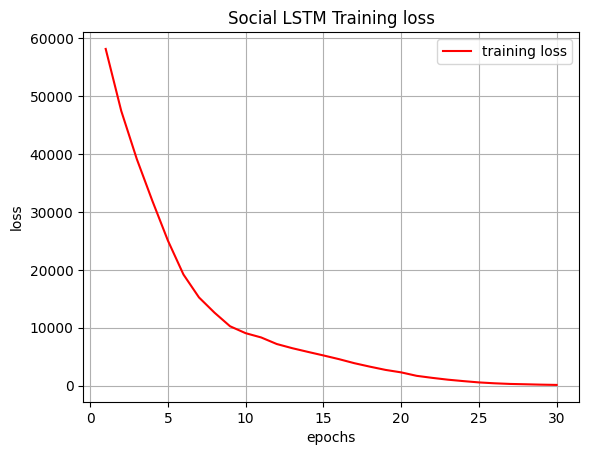

In [65]:
import matplotlib.pyplot as plt

plt.plot(epoch_list, loss_list,color='red', label='training loss')

plt.title("Social LSTM Training loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
all_observed_frames = [] 
all_predicted_positions = [] 
predicted_frame_ids = []
all_ground_truth_positions = []
model.eval()
with torch.no_grad():
    inference_sequences = slstm_utils.generate_inference_frame_sequences(frame_ids, obs_len=obs_len, pred_len=pred_len)

    for window in test_sequenes:
     
        input_tensor, mask_tensor = slstm_utils.generate_tensor_from_frames(window, agent_position_dict, agent_idx_lookup)

        input_tensor = input_tensor.to(device)       
        mask_tensor = mask_tensor.to(device)         
        max_no_agents = input_tensor.size(1)

        
        hidden_states = torch.zeros(max_no_agents, hidden_dim, device=device)
        cell_states = torch.zeros(max_no_agents, hidden_dim, device=device)

    
        observed_frames = input_tensor[:obs_len]
        all_observed_frames.append(observed_frames)


        social_grid_tensor = slstm_utils.compute_social_grids(input_tensor[:obs_len], mask_tensor[:obs_len])

   
        outputs, hidden_states, cell_states = model(input_tensor[:obs_len], social_grid_tensor, hidden_states, cell_states, mask_tensor[:obs_len])

        
        prev_input = input_tensor[obs_len - 1]           
        prev_mask = mask_tensor[obs_len - 1]           

        predicted_position = []

        for t in range(pred_len):
            
            social_grid_step = slstm_utils.compute_social_grids(prev_input.unsqueeze(0), prev_mask.unsqueeze(0))

            output, hidden_states, cell_states = model(prev_input.unsqueeze(0), social_grid_step, hidden_states, cell_states, prev_mask.unsqueeze(0))

            next_pred = output.squeeze(0)  
            predicted_position.append(next_pred)

           
            prev_input_full = torch.zeros(max_no_agents, 2, device=device)
            active_agents = prev_mask.nonzero(as_tuple=True)[0]
            prev_input_full[active_agents] = next_pred[active_agents]
            prev_input = prev_input_full

            prev_mask = (prev_input.sum(dim=1) != 0).float()
        all_predicted_positions.append(torch.stack(predicted_position))
        predicted_frame_ids.append(window[obs_len:])
        gt_positions, _ = slstm_utils.generate_tensor_from_frames(window[obs_len:], agent_position_dict, agent_idx_lookup)
        all_ground_truth_positions.append(gt_positions.to(device))

ade_list = []
fde_list = []

for pred_seq, gt_seq in zip(all_predicted_positions, all_ground_truth_positions):
    mask = (gt_seq.sum(dim=2) != 0).float()
    l2 = torch.norm(pred_seq - gt_seq, dim=2) * mask
    ade_list.append((l2.sum() / mask.sum()).item())
    fde_list.append((l2[-1].sum() / mask[-1].sum()).item())
ADE = sum(ade_list) / len(ade_list)
FDE = sum(fde_list) / len(fde_list)

print(f"ADE: {ADE:.4f}, FDE: {FDE:.4f}")


ADE: 64.8223, FDE: 92.1895


In [74]:
# pred_mapping = {}

# for seq_idx in range(len(all_predicted_positions)):
#     pred_seq = all_predicted_positions[seq_idx]  # shape: (pred_len, max_agents, 2)
#     frame_ids_seq = predicted_frame_ids[seq_idx]  # list of frame IDs corresponding to this pred_seq

#     for t, frame_id in enumerate(frame_ids_seq):
#         positions = []
#         frame_tensor = pred_seq[t]  # (max_agents, 2)

#         for agent_idx in range(frame_tensor.shape[0]):
#             x, y = frame_tensor[agent_idx].cpu().numpy()
#             # ignore inactive agents (zeros)
#             if not (x == 0.0 and y == 0.0):
#                 positions.append((int(x), int(y)))

#         # map to original dataset frame ID
#         orig_frame_id = frame_id_to_orig[frame_id]
#         pred_mapping[orig_frame_id] = positions

# # pred_mapping now maps each original frame ID -> list of predicted positions
# print(pred_mapping)


In [75]:
# frame_idx = 0
# # print(predicted.shape)
# # print(target.shape)
# pred_len, max_agents, _ = predicted.shape
# pred_mapping = {}
# print(len(all_predicted_positions))
# print(len(predicted_frame_ids))
# for i in range(len(predicted_frame_ids)):
#     pred_window = predicted_frame_ids[i]
#     predicted_pos = all_predicted_positions[i]
#     for t, f_idx in enumerate(pred_window):
#         positions = []
#         for agent_id in range(max_agents):
#             x, y = predicted_pos[t, agent_id].cpu().detach().numpy()
#             if not (x == 0 and y == 0): 
#                 positions.append((int(x), int(y)))
#         pred_mapping[frame_id_to_orig[f_idx]] = positions
# print(pred_mapping)

In [182]:
# Convert dict to list of trajectories per agent
# num_agents = len(pred_mapping[list(pred_mapping.keys())[0]])
# pred_traj = [[] for _ in range(num_agents)]

# # Collect positions per agent across frames
# for frame_idx in sorted(pred_mapping.keys()):
#     positions = pred_mapping[frame_idx]
#     for agent_id, pos in enumerate(positions):
#         pred_traj[agent_id].append(pos)

# print(pred_traj)

In [ ]:
# projections from true label.



In [24]:
torch.save(model.state_dict(), "social_lstm_model_version3_correct.pth")

In [73]:

# predicted_frame_ids = list(pred_mapping.keys())
# # print(predicted_frame_ids)
# #print(agent_idx_lookup)
# frame_id = predicted_frame_ids[0]
# print(pred_mapping[frame_id])
# agents = agent_position_dict[frame_id]
# print(agents)

In [ ]:

epochs = 15
epoch_list = []
loss_list = []
videos = ["video0","video2", "video3"]
max_no_agents = 10000
model = s.SocialLSTM( pos_embedding_size=pos_embed_dim, grid_embedding_size=grid_embed_dim,
                   hidden_dim=hidden_dim, grid_size=grid_size, dropout=dropout, max_agents=max_no_agents)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
for epoch in range(epochs):

    print(" starting epoch ",epoch)
    total_loss = 0.0
     
    for video in videos:
        current_dir = os.getcwd()

        file_path = os.path.join(current_dir, "data","annotations","bookstore",video, "annotations.txt")
        processed_df = slstm_utils.data_cleaning(file_path)
        agent_position_dict, frame_ids,frame_id_to_orig = slstm_utils.generate_frame_to_coordinate_map(processed_df)
        agent_idx_lookup,idx_to_agent_id = slstm_utils.agent_hidden_idx_lookup(processed_df)
        sequences = slstm_utils.generate_frame_sequences(frame_ids,obs_len=obs_len, pred_len=pred_len, stride=5)
        
        
        for window in sequences:
        
            input_tensor , mask_tensor = slstm_utils.generate_tensor_from_frames(window,agent_position_dict,agent_idx_lookup )
            social_grid_tensor = slstm_utils.compute_social_grids(input_tensor,mask_tensor)

            input_tensor = input_tensor.to(device)
            mask_tensor = mask_tensor.to(device)
            social_grid_tensor = social_grid_tensor.to(device)
            max_no_agents = input_tensor.size(1)
            

            hidden_states = torch.zeros(max_no_agents, hidden_dim, device=device)
            cell_states = torch.zeros(max_no_agents, hidden_dim, device=device)
            
            

            outputs, hidden_states, cell_states = model(input_tensor, social_grid_tensor, hidden_states, cell_states, mask_tensor)
            

            predicted = outputs[obs_len:]  # future frames
            target = input_tensor[obs_len:]
            target_mask = mask_tensor[obs_len:].unsqueeze(-1)
        
            loss = criterion(predicted * target_mask, target * target_mask)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
            

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(sequences):.4f}")
    epoch_list.append(epoch+1)
    loss_list.append(total_loss/len(sequences))


In [ ]:
# inference code
all_observed_frames = [] 
all_predicted_positions = [] 
predicted_frame_ids = []
all_ground_truth_positions = []
model.eval()
with torch.no_grad():
    current_dir = os.getcwd()

    file_path = os.path.join(current_dir, "data","annotations","bookstore","video1", "annotations.txt")
    processed_df = slstm_utils.data_cleaning(file_path)
    agent_position_dict, frame_ids,frame_id_to_orig = slstm_utils.generate_frame_to_coordinate_map(processed_df)
    agent_idx_lookup,idx_to_agent_id = slstm_utils.agent_hidden_idx_lookup(processed_df)
    inference_sequences = slstm_utils.generate_frame_sequences(frame_ids,obs_len=obs_len, pred_len=pred_len, stride=5)
    
    
    
    for window in inference_sequences:
        input_tensor, mask_tensor = slstm_utils.generate_tensor_from_frames(window, agent_position_dict, agent_idx_lookup)

        input_tensor = input_tensor.to(device)       
        mask_tensor = mask_tensor.to(device)         
        max_no_agents = input_tensor.size(1)

        hidden_states = torch.zeros(max_no_agents, hidden_dim, device=device)
        cell_states = torch.zeros(max_no_agents, hidden_dim, device=device)
        observed_frames = input_tensor[:obs_len]
        all_observed_frames.append(observed_frames)

        social_grid_tensor = slstm_utils.compute_social_grids(input_tensor[:obs_len], mask_tensor[:obs_len])

        outputs, hidden_states, cell_states = model(input_tensor[:obs_len], social_grid_tensor, hidden_states, cell_states, mask_tensor[:obs_len])

        prev_input = input_tensor[obs_len - 1]          
        prev_mask = mask_tensor[obs_len - 1]           

        predicted_position = []

        for t in range(pred_len):
            social_grid_step = slstm_utils.compute_social_grids(prev_input.unsqueeze(0), prev_mask.unsqueeze(0))
            output, hidden_states, cell_states = model(prev_input.unsqueeze(0), social_grid_step, hidden_states, cell_states, prev_mask.unsqueeze(0))
            next_pred = output.squeeze(0) 
            predicted_position.append(next_pred)
            prev_input_full = torch.zeros(max_no_agents, 2, device=device)
            active_agents = prev_mask.nonzero(as_tuple=True)[0]
            prev_input_full[active_agents] = next_pred[active_agents]
            prev_input = prev_input_full
            prev_mask = (prev_input.sum(dim=1) != 0).float()
        all_predicted_positions.append(torch.stack(predicted_position))
        predicted_frame_ids.append(window[obs_len:])
        gt_positions, _ = slstm_utils.generate_tensor_from_frames(window[obs_len:], agent_position_dict, agent_idx_lookup)
        all_ground_truth_positions.append(gt_positions.to(device))

ade_list = []
fde_list = []

for pred_seq, gt_seq in zip(all_predicted_positions, all_ground_truth_positions):
    mask = (gt_seq.sum(dim=2) != 0).float()
    l2 = torch.norm(pred_seq - gt_seq, dim=2) * mask
    ade_list.append((l2.sum() / mask.sum()).item())
    fde_list.append((l2[-1].sum() / mask[-1].sum()).item())

ADE = sum(ade_list) / len(ade_list)
FDE = sum(fde_list) / len(fde_list)

print(f"ADE: {ADE:.4f}, FDE: {FDE:.4f}")


ADE: 70.9551, FDE: 91.2163
